In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2
import glob

In [ ]:
!find /content/drive/MyDrive -name "best.pt"

/content/drive/MyDrive/best.pt
/content/drive/MyDrive/train-2/weights/best.pt


In [ ]:
model = YOLO("/content/drive/MyDrive/train-2/weights/best.pt")

In [ ]:
print(model.names)

{0: 'handrise', 1: 'read', 2: 'write', 3: 'sleep', 4: 'using_device', 5: 'stand', 6: 'look_forward', 7: 'turn_head'}


In [ ]:
!find /content/drive/MyDrive -name "*.jpg" | head

/content/drive/MyDrive/train-2/labels.jpg
/content/drive/MyDrive/train-2/train_batch1.jpg
/content/drive/MyDrive/train-2/train_batch0.jpg
/content/drive/MyDrive/train-2/train_batch2.jpg
/content/drive/MyDrive/train-2/train_batch36320.jpg
/content/drive/MyDrive/train-2/train_batch36321.jpg
/content/drive/MyDrive/train-2/train_batch36322.jpg
/content/drive/MyDrive/train-2/val_batch0_labels.jpg
/content/drive/MyDrive/train-2/val_batch0_pred.jpg
/content/drive/MyDrive/train-2/val_batch1_pred.jpg


In [ ]:
!find /content/drive/MyDrive -type d -name images

In [ ]:
!ls "/content/drive/MyDrive"

 8342243-uhd_3840_2160_25fps.avi  'Colab Notebooks'
 archive.zip.zip		  'Saved from the Google app'
 best.pt			   Smart_Classroom_Project.ipynb
 Classroom			   train-2


In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/train-2/val_batch0_pred.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/drive/MyDrive/train-2/val_batch0_pred.jpg: 640x640 4 handrises, 24 reads, 11 writes, 5 sleeps, 204.5ms
Speed: 8.9ms preprocess, 204.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


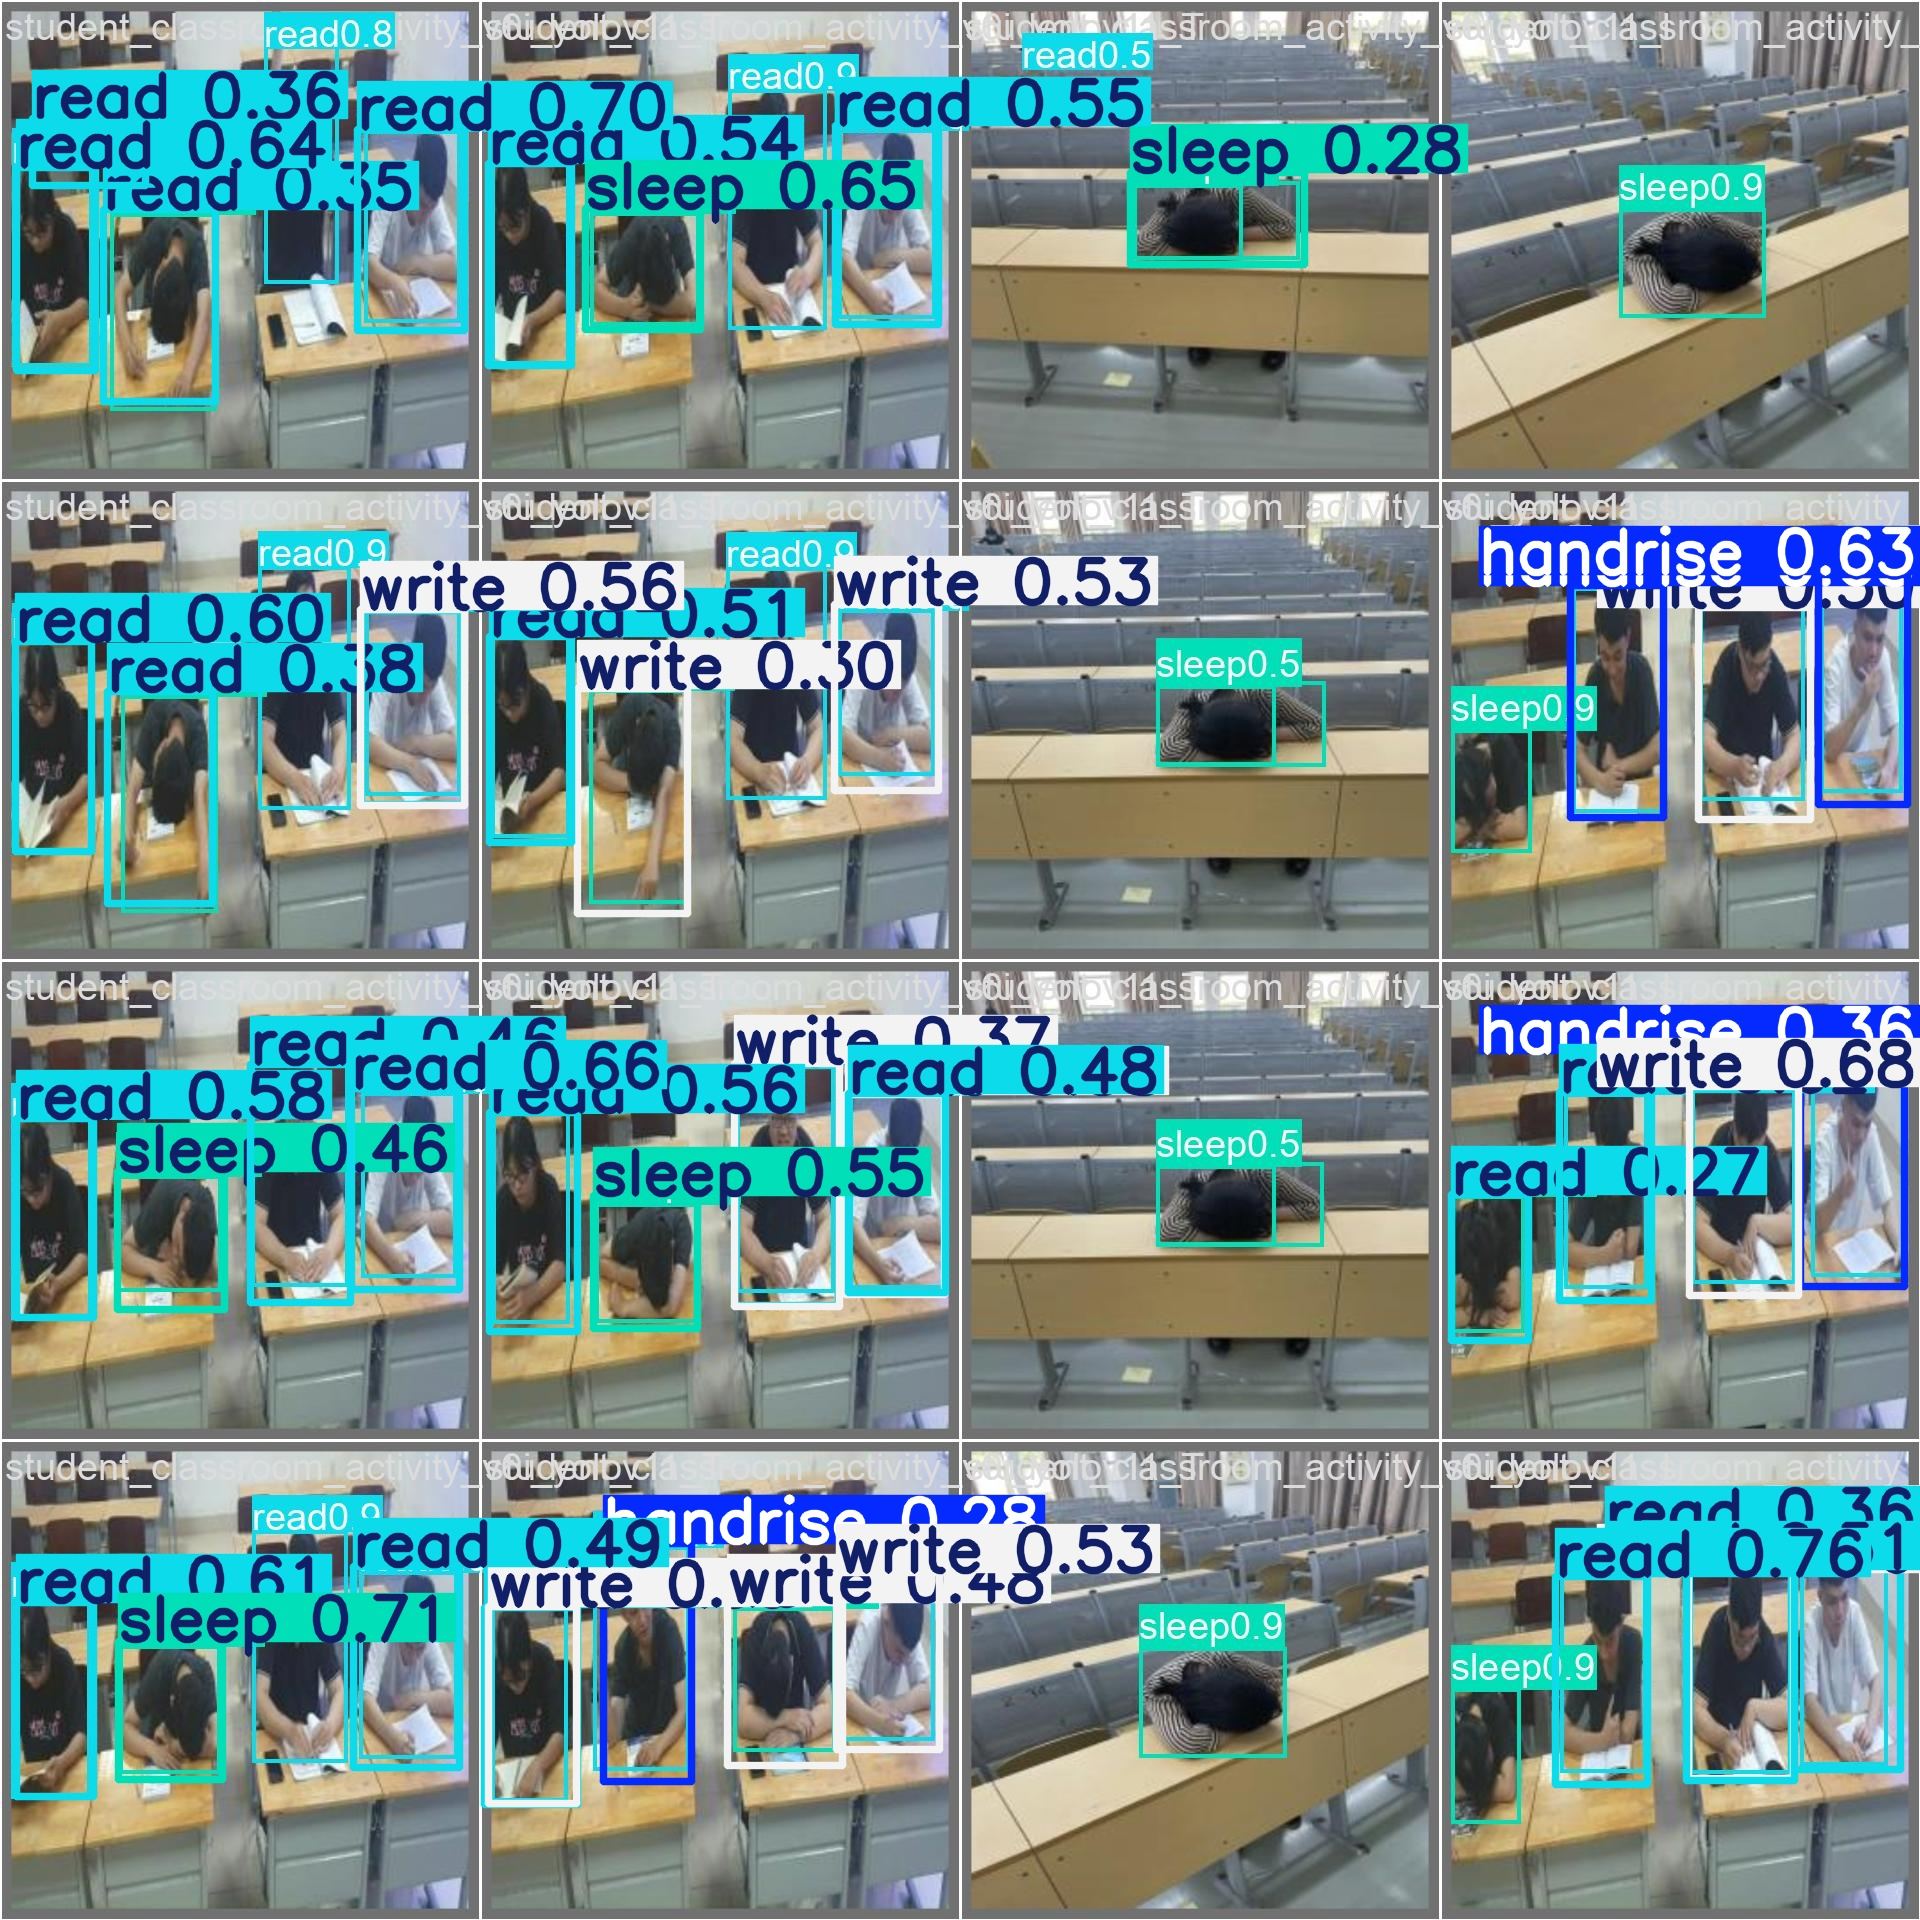

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import glob

result_img = glob.glob("/content/runs/detect/predict/*.jpg")[0]

img = cv2.imread(result_img)
cv2_imshow(img)

In [ ]:
for r in results:
    boxes = r.boxes
    for box in boxes:
        cls = int(box.cls)
        print(model.names[cls])

read
sleep
read
write
read
sleep
read
handrise
handrise
read
read
read
read
write
read
sleep
read
read
write
write
read
read
read
write
read
read
write
read
write
sleep
write
read
read
write
write
read
read
handrise
read
read
write
sleep
handrise
read


In [ ]:
behavior_count = {}

for r in results:
    for box in r.boxes:
        cls = int(box.cls)
        label = model.names[cls]

        if label not in behavior_count:
            behavior_count[label] = 0

        behavior_count[label] += 1

print(behavior_count)

{'read': 24, 'sleep': 5, 'write': 11, 'handrise': 4}
